# Telecom Usage Analysis Walkthrough

This notebook is structured as a sequential walkthrough of how I approached the take-home. The goal is not only to produce the final answers, but also to show how I explored the data, how I decided what to clean, and how I used the data model to answer each question.

## Data Sources

The take-home includes these source files:
- `data/usage_events.parquet`
- `data/profile_installation.parquet`
- `data/sim_card_plan_history.parquet`
- `data/rate_card.parquet`
- `ERD.png`

## Data Model Visual

`ERD.png` is the entity relationship diagram for the take-home. It shows how the telecom usage data is intended to link across the four core datasets:

- `usage_events`: usage facts keyed by `sid` and linked to profiles through `pid`
- `profile_installation`: maps a profile (`pid`) to a SIM / asset (`asset_id`) over time
- `sim_card_plan_history`: maps a SIM / asset (`asset_id`) to a bundle / plan (`bundle_id`) over time
- `rate_card`: stores rating rules by `bundle_id`, country/network (`cc1`, `cc2`), technology, and effective dates

At a high level, the intended path is:

`usage_events` -> `profile_installation` -> `sim_card_plan_history` -> `rate_card`

This join path is important because not every question needs the full chain. One of the main decisions in this notebook is to only clean and join the tables required for the specific question being answered. That keeps the logic easier to explain and avoids unnecessary assumptions.

![ERD](ERD.png)

In [83]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Import the shared table-cleaning helpers used by both the notebook and the script version.
# Each helper wraps a table-specific set of quality checks and returns two things:
# 1. a cleaned dataframe we can safely use downstream, and
# 2. a summary dataframe that shows what was checked and how many rows were removed.
# I use these helpers here so the walkthrough stays aligned with the reproducible script.
from utils.table_cleaning import (
    clean_profile_installation_table,
    clean_rate_card_table,
    clean_sim_card_plan_history_table,
    clean_usage_table,
    utility_checks_reference,
)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

## Step 1: Inspect the Raw Inputs

Before answering any business question, I start by reading each source independently and checking its columns and data types. This helps confirm what each table can answer on its own and where joins will be needed.

In [84]:
usage_events = pd.read_parquet(DATA_DIR / "usage_events.parquet")
print("usage_events")
print("columns:", list(usage_events.columns))
print("dtypes:")
print(usage_events.dtypes)

usage_events
columns: ['sid', 'pid', 'evt_dttm', 'mb', 'cc1', 'cc2', 'tech', 'apn_nm', 'src_nm', 'ld_dttm']
dtypes:
sid                  int64
pid                  int64
evt_dttm    datetime64[ns]
mb                 float64
cc1                float64
cc2                  int64
tech                   str
apn_nm                 str
src_nm                 str
ld_dttm     datetime64[ns]
dtype: object


In [85]:
profile_installation = pd.read_parquet(DATA_DIR / "profile_installation.parquet")
print("profile_installation")
print("columns:", list(profile_installation.columns))
print("dtypes:")
print(profile_installation.dtypes)


profile_installation
columns: ['pid', 'asset_id', 'beg_dttm', 'end_dttm', 'src_cd', 'crt_dttm']
dtypes:
pid                  int64
asset_id             int64
beg_dttm    datetime64[ns]
end_dttm    datetime64[ns]
src_cd                 str
crt_dttm    datetime64[ns]
dtype: object


In [86]:
sim_card_plan_history = pd.read_parquet(DATA_DIR / "sim_card_plan_history.parquet")
print("sim_card_plan_history")
print("columns:", list(sim_card_plan_history.columns))
print("dtypes:")
print(sim_card_plan_history.dtypes)


sim_card_plan_history
columns: ['asset_id', 'bundle_id', 'eff_dttm', 'x_dttm', 'why_cd', 'upd_dttm']
dtypes:
asset_id              int64
bundle_id             int64
eff_dttm     datetime64[ns]
x_dttm       datetime64[ns]
why_cd                  str
upd_dttm     datetime64[ns]
dtype: object


In [87]:
rate_card = pd.read_parquet(DATA_DIR / "rate_card.parquet")
print("rate_card")
print("columns:", list(rate_card.columns))
print("dtypes:")
print(rate_card.dtypes)


rate_card
columns: ['bundle_id', 'cc1', 'cc2', 'tech_cd', 'beg_dttm', 'end_dttm', 'rt_amt', 'curr_cd', 'prio_nbr']
dtypes:
bundle_id             int64
cc1                   int64
cc2                   int64
tech_cd                 str
beg_dttm     datetime64[ns]
end_dttm     datetime64[ns]
rt_amt              float64
curr_cd                 str
prio_nbr              int64
dtype: object


## Step 2: Define a Reusable Cleaning Layer

To keep the notebook and script consistent, I use a shared cleaning utility. The utility creates a cleaned version of each raw table and a summary of what checks were applied. It supports both generic checks and table-specific custom checks.

This is helpful in an interview setting because I can explain the cleaning logic once, then reuse it question by question.

In [88]:
utility_checks_reference()

,check_type,what_it_ensures
0,check_duplicates,Keeps one row per duplicate key according to t...
1,check_not_null,Requires non-null values in join-critical or r...
2,check_non_negative,Requires numeric values to be non-negative or ...
3,check_valid_window,Requires temporal windows to end after they be...
4,check_comparison,Requires one column to satisfy a comparison ag...
5,check_custom,Allows table-specific business rules not cover...


## Step 3: Create Clean Versions of All Tables

After inspecting the raw inputs, I create clean versions of each table up front. This makes the later question-by-question analysis easier to read because every answer can clearly state whether it uses a raw table or a cleaned table.

In [89]:
# Run the shared cleaning helpers once near the top of the notebook.
# This gives us a consistent "best available" version of each table before we answer questions.
# The goal is not to over-clean blindly, but to make the quality checks explicit and reusable.
usage_events_clean_result = clean_usage_table(usage_events)
profile_installation_clean_result = clean_profile_installation_table(profile_installation)
sim_card_plan_history_clean_result = clean_sim_card_plan_history_table(sim_card_plan_history)
rate_card_clean_result = clean_rate_card_table(rate_card)

# Pull out the cleaned dataframes that we will reference throughout the walkthrough.
usage_clean = usage_events_clean_result.cleaned_df.copy()
profile_installation_clean = profile_installation_clean_result.cleaned_df.copy()
sim_card_plan_history_clean = sim_card_plan_history_clean_result.cleaned_df.copy()
rate_card_clean = rate_card_clean_result.cleaned_df.copy()

# Pull out the check summaries so we can explain not just what we kept, but why we trust it.
usage_clean_summary = usage_events_clean_result.summary_df.copy()
profile_installation_clean_summary = profile_installation_clean_result.summary_df.copy()
sim_card_plan_history_clean_summary = sim_card_plan_history_clean_result.summary_df.copy()
rate_card_clean_summary = rate_card_clean_result.summary_df.copy()

pd.DataFrame(
    {
        "table": [
            "usage_events",
            "profile_installation",
            "sim_card_plan_history",
            "rate_card",
        ],
        "raw_rows": [
            len(usage_events),
            len(profile_installation),
            len(sim_card_plan_history),
            len(rate_card),
        ],
        "clean_rows": [
            len(usage_clean),
            len(profile_installation_clean),
            len(sim_card_plan_history_clean),
            len(rate_card_clean),
        ],
    }
)

,table,raw_rows,clean_rows
0,usage_events,30,25
1,profile_installation,13,12
2,sim_card_plan_history,14,13
3,rate_card,16,14


## Step 4: Answer the Questions in README Order

### Question 1: Create a Line Chart of Total Usage (MB) Per Day

This question only needs the cleaned `usage_events` table. Once the event-level data is deduplicated and filtered to valid records, I can aggregate to the day level and plot total usage.

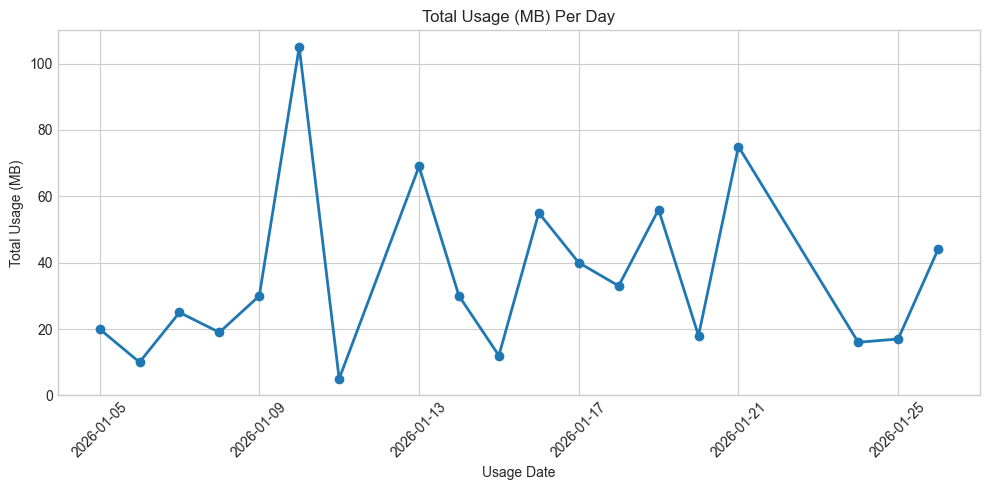

(   usage_date  total_usage_mb
 0  2026-01-05            20.0
 1  2026-01-06            10.0
 2  2026-01-07            25.0
 3  2026-01-08            19.0
 4  2026-01-09            30.0
 5  2026-01-10           105.0
 6  2026-01-11             5.0
 7  2026-01-13            69.0
 8  2026-01-14            30.0
 9  2026-01-15            12.0
 10 2026-01-16            55.0
 11 2026-01-17            40.0
 12 2026-01-18            33.0
 13 2026-01-19            56.0
 14 2026-01-20            18.0
 15 2026-01-21            75.0
 16 2026-01-24            16.0
 17 2026-01-25            17.0
 18 2026-01-26            44.0,
 None)

In [90]:
# Aggregate cleaned usage events to the day level.
daily_usage = (
    usage_clean.groupby("usage_date", as_index=False)["mb"]
    .sum()
    .rename(columns={"mb": "total_usage_mb"})
    .sort_values("usage_date")
)

# Plot total usage in MB per day.
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_usage["usage_date"], daily_usage["total_usage_mb"], marker="o", linewidth=2)
ax.set_title("Total Usage (MB) Per Day")
ax.set_xlabel("Usage Date")
ax.set_ylabel("Total Usage (MB)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

daily_usage, plt.show()

### Question 2: Which `sim_card_id` Had the Highest Total Usage?

This is the first question where the data model matters. `usage_events` does not contain `sim_card_id` directly, so I need to use `profile_installation` to map each event's `pid` to the active `asset_id` at the event timestamp.

#### Prepare `profile_installation` for the Temporal Join

Before linking, I check that profile assignment windows are valid. Since the join is time-based, bad windows can create incorrect or ambiguous matches.

In [91]:
# Review the checks applied to `profile_installation` before using it in the temporal join.
# This matters because the sim-card answer depends on matching each event to the correct active
# profile window. If the profile windows are invalid, overlapping, or missing key join fields,
# the downstream sim-card attribution can be wrong even if the usage table itself is clean.
profile_installation_clean_summary

,check_name,description,rows_before,rows_removed,rows_after
0,require_profile_join_keys,"Require non-null values in ['pid', 'asset_id',...",13,0,13
1,require_valid_profile_window,Require valid windows where end_dttm is null o...,13,1,12


In [92]:
# Use the data model to map usage events to sim cards:
# usage_events.pid -> profile_installation.asset_id (the sim_card_id),
# using the profile window active at the event timestamp.

# Vectorized temporal join:
# 1. Merge usage events to profile windows by `pid`
# 2. Keep only profile windows active at the event timestamp
# 3. If multiple windows match, keep the most recent valid one
usage_profile_candidates = usage_clean.merge(
    profile_installation_clean,
    on="pid",
    how="left",
    suffixes=("", "_profile"),
)

usage_profile_candidates = usage_profile_candidates[
    (usage_profile_candidates["beg_dttm"] <= usage_profile_candidates["evt_dttm"])
    & (
        usage_profile_candidates["end_dttm"].isna()
        | (usage_profile_candidates["evt_dttm"] < usage_profile_candidates["end_dttm"])
    )
].copy()

usage_with_sim = (
    usage_profile_candidates.sort_values(
        ["sid", "beg_dttm", "crt_dttm", "end_dttm", "asset_id"],
        ascending=[True, False, False, False, False],
    )
    .drop_duplicates(subset=["sid"], keep="first")
    [["sid", "pid", "asset_id", "mb"]]
    .rename(columns={"asset_id": "sim_card_id"})
)

usage_with_sim.head()

,sid,pid,sim_card_id,mb
0,1,100,1000.0,100.0
3,2,100,1001.0,55.0
5,3,100,1001.0,75.0
6,4,101,1002.0,20.0
7,5,102,1003.0,40.0


In [93]:
# Aggregate usage by sim card and sort from highest total usage to lowest.
sim_usage = (
    usage_with_sim.groupby("sim_card_id", dropna=True)["mb"]
    .sum()
    .reset_index()
    .rename(columns={"mb": "total_usage_mb"})
    .sort_values("total_usage_mb", ascending=False)
)

sim_usage

,sim_card_id,total_usage_mb
1,1001.0,160.0
0,1000.0,100.0
2,1002.0,94.0
4,1004.0,89.0
7,1007.0,77.0
5,1005.0,57.0
3,1003.0,40.0
8,1008.0,30.0
6,1006.0,5.0


In [94]:
# The first row is the sim card with the highest total usage.
sim_usage.iloc[0]

sim_card_id       1001.0
total_usage_mb     160.0
Name: 1, dtype: float64

### Question 3: How Many Usage Events Resolved to 3G After Cleanup?

For this question, I pause and re-evaluate the join path. Because `3G` resolution comes from normalizing the raw `tech` values in `usage_events`, I do not need any downstream joins here.

Below, I confirm that decision explicitly by checking which cleaned table is required for the answer and then inspecting how the raw `tech` values roll up into the normalized technology buckets.

In [95]:
# Inspect the raw technology values and the cleaned technology bucket.
# The cleaned `tech_clean` column is created during `usage_events` cleaning.
usage_clean[["tech", "tech_clean"]].drop_duplicates().sort_values(["tech_clean", "tech"])

,tech,tech_clean
27,CDMA,3G
28,GSM,3G
5,4G,4G
19,4g,4G
0,LTE,4G
3,lte,4G
16,5G,5G
2,5g,5G
9,NR,5G
22,NaN,NaN


In [96]:
# Count how many cleaned usage events resolved to the normalized `3G` bucket.
three_g_event_count = (usage_clean["tech_clean"] == "3G").sum()
three_g_event_count

np.int64(2)

### Question 4: How Many Duplicate Usage Events Did We Identify?

This question goes back to the raw feed. I answer it directly from `usage_events` because duplicate identification is about the original event key (`sid`), not the cleaned downstream model.

Below, I validate that scope explicitly and then show the duplicate records so the decision is transparent rather than just asserted.

In [97]:
# Count duplicate event rows using `sid` as the event identifier.
# `keep='last'` counts earlier copies as duplicates when a later loaded version exists.
duplicate_usage_event_count = usage_events.duplicated(subset=["sid"], keep="last").sum()
duplicate_usage_event_count

np.int64(2)

In [98]:
# Show the duplicate rows so we can inspect the conflicting copies directly.
usage_events[usage_events.duplicated(subset=["sid"], keep=False)].sort_values(["sid", "ld_dttm"])

,sid,pid,evt_dttm,mb,cc1,cc2,tech,apn_nm,src_nm,ld_dttm
1,2,100,2026-01-16 08:00:00,50.0,310.0,260,4g,internet,usage_1.parquet,2026-01-16 09:00:00
18,2,100,2026-01-16 08:00:00,50.0,310.0,260,4g,internet,usage_2.parquet,2026-01-16 10:00:00
19,2,100,2026-01-16 08:00:00,55.0,310.0,260,4g,internet,usage_3.parquet,2026-01-16 11:00:00


### Question 5: What Is the Cost of All Data Used in the Linked Data?

This is the most model-dependent question. To price usage correctly, I need the full cleaned linkage path: usage event -> active sim card -> active bundle -> matching rate rule.

This is also where I need to be most explicit about assumptions, because unmatched rows, overlapping windows, and fallback rate rules all affect the final total.

Below, I walk through that linkage in order and use the returned resolution columns to keep the pricing logic auditable.

In [99]:
# Review the cleaning summaries for the three downstream tables used in the linkage.
# I do this before pricing because the cost question is the most sensitive to join quality.
# A missing SIM assignment, an invalid plan window, or a bad rate row can each break the full
# chain independently, so this summary tells us where the main linkage risks are.
pd.concat(
    [
        profile_installation_clean_summary.assign(table="profile_installation"),
        sim_card_plan_history_clean_summary.assign(table="sim_card_plan_history"),
        rate_card_clean_summary.assign(table="rate_card"),
    ],
    ignore_index=True,
)[["table", "check_name", "description", "rows_removed", "rows_after"]]

,table,check_name,description,rows_removed,rows_after
0,profile_installation,require_profile_join_keys,"Require non-null values in ['pid', 'asset_id',...",0,13
1,profile_installation,require_valid_profile_window,Require valid windows where end_dttm is null o...,1,12
2,sim_card_plan_history,require_plan_join_keys,"Require non-null values in ['asset_id', 'bundl...",0,14
3,sim_card_plan_history,require_valid_plan_window,Require valid windows where x_dttm is null or ...,1,13
4,rate_card,require_rate_join_keys,"Require non-null values in ['bundle_id', 'cc1'...",0,16
5,rate_card,require_usd_currency,Require curr_cd to equal USD.,1,15
6,rate_card,require_non_negative_rt_amt,Require rt_amt >= 0.,1,14
7,rate_card,require_valid_rate_window,Require valid windows where end_dttm is null o...,0,14


In [100]:
# Build the fully linked usage dataset using the cleaned tables.
# I use `build_linked_usage` here because this question is where the full ERD actually matters.
# Earlier questions could be answered from `usage_events` alone or with one downstream table,
# but pricing requires us to preserve the intended business path from event -> SIM -> plan -> rate.
# `build_linked_usage` encapsulates that path for each cleaned usage event:
# 1. Find the active sim card in `profile_installation_clean` at the event timestamp.
# 2. Find the active bundle / plan in `sim_card_plan_history_clean` for that sim card.
# 3. Find the matching rate rule in `rate_card_clean` using bundle, geography, technology, and date.
# 4. Calculate `cost_usd` as `mb * rate_per_mb_usd` when a valid rate is found.
# The function also returns resolution columns so we can audit why a row matched, fell back, or failed.
# That is important for the interview because it shows the pricing result is inspectable, not a black box.
from utils.analysis_helpers import build_linked_usage

linked_usage = build_linked_usage(
    usage_clean,
    profile_installation_clean,
    sim_card_plan_history_clean,
    rate_card_clean,
)

linked_usage[[
    "sid",
    "asset_id",
    "bundle_id",
    "mb",
    "rate_per_mb_usd",
    "cost_usd",
    "profile_resolution",
    "plan_resolution",
    "rate_resolution",
]].head(10)

,sid,asset_id,bundle_id,mb,rate_per_mb_usd,cost_usd,profile_resolution,plan_resolution,rate_resolution
0,1,1000.0,2000.0,100.0,0.010,1.000,profile_match,plan_match,exact_geo_exact_tech
1,13,1001.0,2000.0,12.0,0.010,0.120,profile_match,plan_match,exact_geo_exact_tech
2,2,1001.0,2000.0,55.0,0.010,0.550,profile_match,plan_match,exact_geo_exact_tech
3,14,1001.0,2001.0,18.0,0.008,0.144,profile_match,plan_match,exact_geo_exact_tech
4,3,1001.0,2001.0,75.0,0.012,0.900,profile_match,plan_match,exact_geo_exact_tech
5,4,1002.0,2000.0,20.0,0.010,0.200,profile_match,plan_overlap_resolved_reason_rank,exact_geo_exact_tech
6,16,1002.0,2000.0,25.0,0.018,0.450,profile_match,plan_overlap_resolved_reason_rank,exact_geo_exact_tech
7,23,1002.0,2000.0,19.0,0.015,0.285,profile_match,plan_overlap_resolved_reason_rank,exact_geo_fallback_tech
8,28,1002.0,2000.0,15.0,NaN,NaN,profile_match,plan_overlap_resolved_reason_rank,missing_cc1
9,29,1002.0,2000.0,15.0,NaN,NaN,profile_match,plan_overlap_resolved_reason_rank,no_geo_rate_match


In [101]:
# Sum the rated usage cost across all linked rows.
# Rows that cannot be fully linked or rated have null cost and are treated as zero in the total.
total_linked_cost_usd = linked_usage["cost_usd"].fillna(0).sum()
total_linked_cost_usd

np.float64(11.138000000000002)